# Denoising Diffusion Probabilistic Models

## 0. Prelim

First, we have a set of $N$ data samples $\mathcal X=\{x_i|i\in \mathbb Z_N \}$, assumed uniquely sampled from an unknown distribution $x_i\sim p_{\text{data}}$.

The MNIST dataset is a good example. In this case, $x_i\in\mathbb R^{784}$.

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

import os
os.makedirs('../0.Data/', exist_ok=True)
train_data = datasets.MNIST('../0.Data/', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../0.Data/', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(f"Loaded {len(train_data)} train, {len(test_data)} test samples")

Loaded 60000 train, 10000 test samples


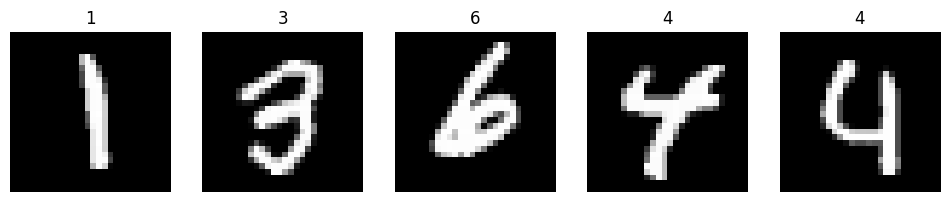

Batch shape: torch.Size([128, 784])
Single image shape: torch.Size([784])


In [3]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].view(28, 28)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')
plt.show()

print(f"Batch shape: {images.shape}")
print(f"Single image shape: {images[0].shape}")

## 1. Modelling

Unlike the VAE architecture, DDPMs use a *Fixed* encoder layer, gradually noising the input data from $x_0$ to Gaussian Noise $x_L$. For such process, a linear interpolation encoder is used as below.
$$p(x_i|x_{i-1}):=\mathcal N(x_i;\sqrt{1-\beta^2_i}x_{i-1},\beta^2_i\mathbf I)$$